# Qualitative features notebook

## Generating test data

In [ ]:
import os
# Specify the desired number of images
desired_count = 100

# Generate images one by one until the desired count is reached
while True:
    !python3 ../samples_generator/samples_generator.py --num_images 5 --img_size 500 --specified_angle 90 --output_dir ../../tests/generated_samples/triangle/
    !python3 ../line_detector/line_detector.py --folder_path ../../tests/generated_samples/triangle/

    # Check the number of files in the folder
    path, dirs, files = next(os.walk("../../tests/generated_samples/triangle/"))
    file_count = len(files)
    print(f"Total images: {file_count}")

    # Break the loop if the desired count is reached
    if file_count >= desired_count:
        break

print(f"Number of test images: {file_count}")

### Generate squares

In [1]:
import os
# Specify the desired number of images
desired_count = 100

# Generate images one by one until the desired count is reached
while True:
    !python3 ../samples_generator/square_generator.py --num_images 10 --img_size 500 --output_dir ../../tests/generated_samples/square/
    !python3 ../line_detector/line_detector.py --folder_path ../../tests/generated_samples/square/ --num_lines 4

    # Check the number of files in the folder
    path, dirs, files = next(os.walk("../../tests/generated_samples/square/"))
    file_count = len(files)
    print(f"Total images: {file_count}")

    # Break the loop if the desired count is reached
    if file_count >= desired_count:
        break

print(f"Number of test images: {file_count}")

Total images: 2
Total images: 3
Total images: 4
Total images: 5
Total images: 6
Total images: 6
Total images: 7
Total images: 8
Total images: 9
Total images: 10
Total images: 10
Total images: 11
Total images: 12
Total images: 13
Total images: 14
Total images: 14
Total images: 15
Total images: 16
Total images: 17
Total images: 18
Total images: 18
Total images: 19
Total images: 20
Total images: 21
Total images: 22
Total images: 22
Total images: 23
Total images: 24
Total images: 25
Total images: 26
Total images: 26
Total images: 27
Total images: 28
Total images: 29
Total images: 30
Total images: 30
Total images: 31
Total images: 32
Total images: 33
Total images: 34
Total images: 34
Total images: 35
Total images: 36
Total images: 37
Total images: 38
Total images: 38
Total images: 39
Total images: 40
Total images: 41
Total images: 42
Total images: 42
Total images: 43
Total images: 44
Total images: 45
Total images: 46
Total images: 46
Total images: 47
Total images: 48
Total images: 49
Total 

### Generate squares

In [ ]:
import os

# Generate 500 images of size 100x100
!python3 ../samples_generator/square_generator.py --num_images 10 --img_size 250 --output_dir ../../tests/squares/

## Analyze training results

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../../training_results/qualitative_features.csv')

# Ensure node_id is a string to prevent any unintended type interpretations
df['node_id'] = df['node_id'].astype(str)
df['labels'] = df['labels'].astype(str)  # Ensure labels are treated as string

# Combine 'node_id' and 'labels' for a unique identifier and legend information
df['node_label'] = df['node_id'] + " - " + df['labels']

# Get the latest (or max) relation count for each node_label to order the legend
latest_relation_count = df.groupby('node_label')['relation_count'].max().sort_values(ascending=False)

# Create a sorted list of node_labels based on the latest relation count
sorted_node_labels = latest_relation_count.index.tolist()

# Pivot the DataFrame to have iterations as index and each unique node_label as a column
pivot_df = df.pivot_table(index='iteration', columns='node_label', values='relation_count', aggfunc='max')

# Reorder pivot_df columns based on the sorted node_labels
pivot_df = pivot_df[sorted_node_labels]

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))

# Plot and use the colormap for a wider variety of colors
pivot_df.plot(kind='line', ax=ax, cmap='tab10')

# Title and labels
plt.title('Number of Inbound Links per Node Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Inbound Links')

# Adjust legend - Since we have combined node_id and labels, it will show both
plt.legend(title='Node ID - Label', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to accommodate the legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

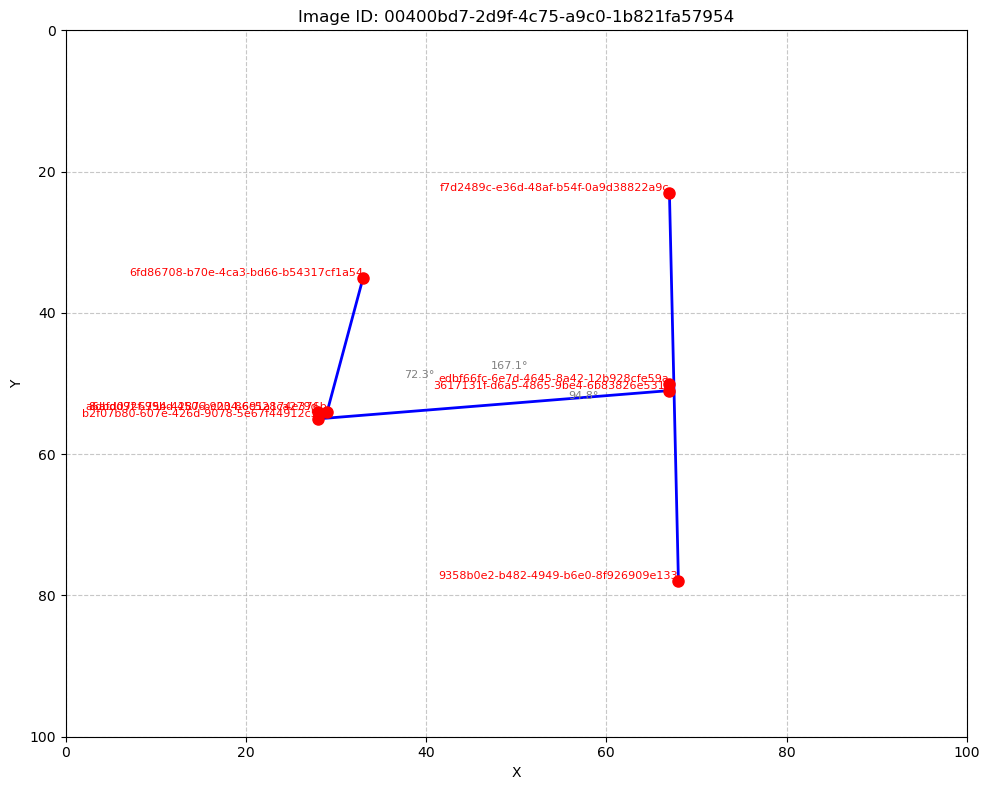

In [12]:
import json
import matplotlib.pyplot as plt
import math

# Your JSON data as a string (remove the timestamps)
json_str = '''
{
	"operation": "train",
	"image_id": "00400bd7-2d9f-4c75-a9c0-1b821fa57954",
	"lines": [
		{
			"id": "a22f0adf-7ec1-462f-a38d-ade85a1f0add",
			"x1": 28,
			"y1": 55,
			"x2": 67,
			"y2": 51,
			"length": 39
		},
		{
			"id": "54f112a4-83fe-4d4a-989f-a7fc5d0b6e5e",
			"x1": 29,
			"y1": 54,
			"x2": 33,
			"y2": 35,
			"length": 19
		},
		{
			"id": "4f238e8d-a99b-41ab-8b5b-f41a4b44acc1",
			"x1": 67,
			"y1": 23,
			"x2": 68,
			"y2": 78,
			"length": 55
		}
	],
	"parameters": {
		"concept_name": "mnist_four",
		"image_path": "/opt/nuclio/shared_storage/mnist_fours/mnist_four_00097.png",
		"session_id": "cdc7eba0-e881-4375-87f8-9bd5e875b44d"
	},
	"points": [
		{
			"id": "a6afd07f-6754-4287-bc23-86c528ca279d",
			"x": 28,
			"y": 54,
			"angle": 70,
			"type": "angle_point",
			"line1": "a22f0adf-7ec1-462f-a38d-ade85a1f0add",
			"line2": "54f112a4-83fe-4d4a-989f-a7fc5d0b6e5e"
		},
		{
			"id": "edbf66fc-6e7d-4645-8a42-12b928cfe59a",
			"x": 67,
			"y": 50,
			"angle": 95,
			"type": "angle_point",
			"line1": "a22f0adf-7ec1-462f-a38d-ade85a1f0add",
			"line2": "4f238e8d-a99b-41ab-8b5b-f41a4b44acc1"
		},
		{
			"id": "b2f07b80-607e-426d-9078-5e67f44912c5",
			"x": 28,
			"y": 55,
			"type": "endpoint",
			"line": "a22f0adf-7ec1-462f-a38d-ade85a1f0add"
		},
		{
			"id": "3617131f-d6a5-4865-9be4-6b83826e531f",
			"x": 67,
			"y": 51,
			"type": "endpoint",
			"line": "a22f0adf-7ec1-462f-a38d-ade85a1f0add"
		},
		{
			"id": "8dbdd92f-99bd-4506-9004-691a174e376b",
			"x": 29,
			"y": 54,
			"type": "endpoint",
			"line": "54f112a4-83fe-4d4a-989f-a7fc5d0b6e5e"
		},
		{
			"id": "6fd86708-b70e-4ca3-bd66-b54317cf1a54",
			"x": 33,
			"y": 35,
			"type": "endpoint",
			"line": "54f112a4-83fe-4d4a-989f-a7fc5d0b6e5e"
		},
		{
			"id": "f7d2489c-e36d-48af-b54f-0a9d38822a9c",
			"x": 67,
			"y": 23,
			"type": "endpoint",
			"line": "4f238e8d-a99b-41ab-8b5b-f41a4b44acc1"
		},
		{
			"id": "9358b0e2-b482-4949-b6e0-8f926909e133",
			"x": 68,
			"y": 78,
			"type": "endpoint",
			"line": "4f238e8d-a99b-41ab-8b5b-f41a4b44acc1"
		}
	]
}
'''

# Parse the JSON data
data = json.loads(json_str)

# Create a new figure
plt.figure(figsize=(10, 8))

# Function to calculate angle between two lines
def calculate_angle(line1, line2):
    dx1 = line1['x2'] - line1['x1']
    dy1 = line1['y2'] - line1['y1']
    dx2 = line2['x2'] - line2['x1']
    dy2 = line2['y2'] - line2['y1']
    
    angle1 = math.atan2(dy1, dx1)
    angle2 = math.atan2(dy2, dx2)
    
    angle = abs(angle1 - angle2)
    angle = min(angle, 2*math.pi - angle)
    return math.degrees(angle)

# Plot lines and calculate all angles
lines = data['lines']
for i, line in enumerate(lines):
    plt.plot([line['x1'], line['x2']], [line['y1'], line['y2']], 'b-', linewidth=2)
    
    for j, other_line in enumerate(lines[i+1:], start=i+1):
        angle = calculate_angle(line, other_line)
        mid_x = (line['x1'] + line['x2'] + other_line['x1'] + other_line['x2']) / 4
        mid_y = (line['y1'] + line['y2'] + other_line['y1'] + other_line['y2']) / 4
        plt.text(mid_x, mid_y, f"{angle:.1f}°", fontsize=8, ha='center', va='center', color='gray')

# Plot angle points from JSON
for point in data['points']:
    plt.plot(point['x'], point['y'], 'ro', markersize=8)
    plt.text(point['x'], point['y'], point['id'], fontsize=8, ha='right', va='bottom', color='red')

# Set the axis limits
plt.xlim(0, 100)
plt.ylim(0, 100)

# Invert the y-axis to match image coordinates
plt.gca().invert_yaxis()

# Add labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Image ID: {data['image_id']}")

# Add a grid
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

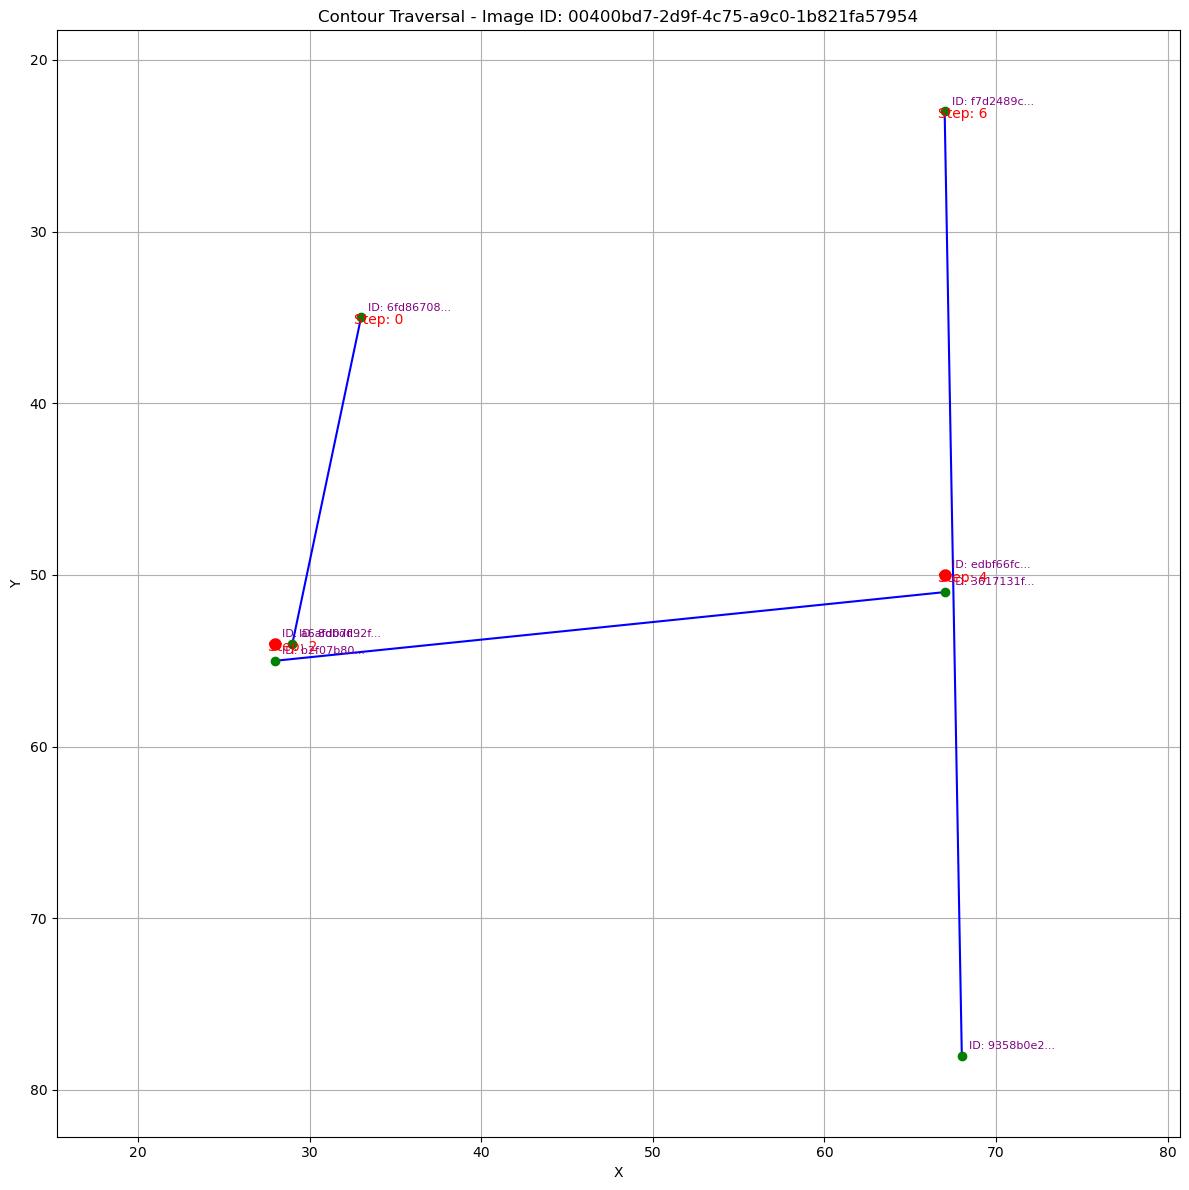


Traversal Order:
0: Point 6fd86708-b70e-4ca3-bd66-b54317cf1a54 (33.0, 35.0)
1: Line 54f112a4-83fe-4d4a-989f-a7fc5d0b6e5e
2: Point a6afd07f-6754-4287-bc23-86c528ca279d (28.0, 54.0)
3: Line a22f0adf-7ec1-462f-a38d-ade85a1f0add
4: Point edbf66fc-6e7d-4645-8a42-12b928cfe59a (67.0, 50.0)
5: Line 4f238e8d-a99b-41ab-8b5b-f41a4b44acc1
6: Point f7d2489c-e36d-48af-b54f-0a9d38822a9c (67.0, 23.0)


In [43]:
import json
import math
import matplotlib.pyplot as plt
from typing import Dict, List, Union
from pydantic import BaseModel

# Paste your JSON string here
json_string = """
{
    "operation": "train",
    "image_id": "00400bd7-2d9f-4c75-a9c0-1b821fa57954",
    "lines": [
        {
            "id": "a22f0adf-7ec1-462f-a38d-ade85a1f0add",
            "x1": 28,
            "y1": 55,
            "x2": 67,
            "y2": 51,
            "length": 39
        },
        {
            "id": "54f112a4-83fe-4d4a-989f-a7fc5d0b6e5e",
            "x1": 29,
            "y1": 54,
            "x2": 33,
            "y2": 35,
            "length": 19
        },
        {
            "id": "4f238e8d-a99b-41ab-8b5b-f41a4b44acc1",
            "x1": 67,
            "y1": 23,
            "x2": 68,
            "y2": 78,
            "length": 55
        }
    ],
    "parameters": {
        "concept_name": "mnist_four",
        "image_path": "/opt/nuclio/shared_storage/mnist_fours/mnist_four_00097.png",
        "session_id": "cdc7eba0-e881-4375-87f8-9bd5e875b44d"
    },
    "points": [
        {
            "id": "a6afd07f-6754-4287-bc23-86c528ca279d",
            "x": 28,
            "y": 54,
            "angle": 70,
            "type": "angle_point",
            "line1": "a22f0adf-7ec1-462f-a38d-ade85a1f0add",
            "line2": "54f112a4-83fe-4d4a-989f-a7fc5d0b6e5e"
        },
        {
            "id": "edbf66fc-6e7d-4645-8a42-12b928cfe59a",
            "x": 67,
            "y": 50,
            "angle": 95,
            "type": "angle_point",
            "line1": "a22f0adf-7ec1-462f-a38d-ade85a1f0add",
            "line2": "4f238e8d-a99b-41ab-8b5b-f41a4b44acc1"
        },
        {
            "id": "b2f07b80-607e-426d-9078-5e67f44912c5",
            "x": 28,
            "y": 55,
            "type": "endpoint",
            "line": "a22f0adf-7ec1-462f-a38d-ade85a1f0add"
        },
        {
            "id": "3617131f-d6a5-4865-9be4-6b83826e531f",
            "x": 67,
            "y": 51,
            "type": "endpoint",
            "line": "a22f0adf-7ec1-462f-a38d-ade85a1f0add"
        },
        {
            "id": "8dbdd92f-99bd-4506-9004-691a174e376b",
            "x": 29,
            "y": 54,
            "type": "endpoint",
            "line": "54f112a4-83fe-4d4a-989f-a7fc5d0b6e5e"
        },
        {
            "id": "6fd86708-b70e-4ca3-bd66-b54317cf1a54",
            "x": 33,
            "y": 35,
            "type": "endpoint",
            "line": "54f112a4-83fe-4d4a-989f-a7fc5d0b6e5e"
        },
        {
            "id": "f7d2489c-e36d-48af-b54f-0a9d38822a9c",
            "x": 67,
            "y": 23,
            "type": "endpoint",
            "line": "4f238e8d-a99b-41ab-8b5b-f41a4b44acc1"
        },
        {
            "id": "9358b0e2-b482-4949-b6e0-8f926909e133",
            "x": 68,
            "y": 78,
            "type": "endpoint",
            "line": "4f238e8d-a99b-41ab-8b5b-f41a4b44acc1"
        }
    ]
}
"""

class Point(BaseModel):
    id: str
    x: float
    y: float
    type: str
    angle: float = None
    line: str = None
    line1: str = None
    line2: str = None

class Line(BaseModel):
    id: str
    x1: float
    y1: float
    x2: float
    y2: float
    length: float

class InputData(BaseModel):
    image_id: str
    lines: List[Line]
    points: List[Point]
    parameters: Dict[str, str]

def traverse_contour(input_data: InputData) -> List[Union[Point, Line]]:
    points = {p.id: p for p in input_data.points}
    lines = {l.id: l for l in input_data.lines}
    
    # Find the top-left point (2x + y) among all points
    start_point = min(points.values(), key=lambda p: (2*p.x + p.y))
    
    traversal = []
    visited_points = set()
    visited_lines = set()

    def get_connected_lines(point: Point) -> List[Line]:
        connected = []
        for line_id in [point.line, point.line1, point.line2]:
            if line_id and line_id not in visited_lines:
                connected.append(lines[line_id])
        return connected

    def get_next_point(line: Line, current_point: Point) -> Point:
        # First, try to find an angle point on the line
        angle_points = [p for p in points.values() if p.type == 'angle_point' and 
                        (p.line1 == line.id or p.line2 == line.id) and 
                        p.id != current_point.id]
        
        if angle_points:
            # If there are angle points, choose the one that's not the current point
            return angle_points[0]
        else:
            # If no angle point, use the endpoint
            if line.x1 == current_point.x and line.y1 == current_point.y:
                return next(p for p in points.values() if p.x == line.x2 and p.y == line.y2)
            else:
                return next(p for p in points.values() if p.x == line.x1 and p.y == line.y1)

    def sort_lines_clockwise(current_point: Point, connected_lines: List[Line]) -> List[Line]:
        def angle_with_x_axis(line: Line):
            dx = line.x2 - line.x1 if line.x1 == current_point.x and line.y1 == current_point.y else line.x1 - line.x2
            dy = line.y2 - line.y1 if line.x1 == current_point.x and line.y1 == current_point.y else line.y1 - line.y2
            angle = math.atan2(-dy, dx)  # Negative dy because y-axis is inverted
            return angle if angle >= 0 else angle + 2 * math.pi

        return sorted(connected_lines, key=angle_with_x_axis)

    def dfs(current_point: Point):
        visited_points.add(current_point.id)
        traversal.append(current_point)

        connected_lines = get_connected_lines(current_point)
        sorted_lines = sort_lines_clockwise(current_point, connected_lines)

        for line in sorted_lines:
            if line.id not in visited_lines:
                visited_lines.add(line.id)
                traversal.append(line)
                next_point = get_next_point(line, current_point)
                if next_point.id not in visited_points:
                    dfs(next_point)

    dfs(start_point)
    return traversal

# Parse JSON and traverse contour
json_data = json.loads(json_string)
input_data = InputData.parse_obj(json_data)
traversal_result = traverse_contour(input_data)

# Visualization
plt.figure(figsize=(12, 12))
plt.title(f"Contour Traversal - Image ID: {input_data.image_id}")

# Plot lines
for line in input_data.lines:
    plt.plot([line.x1, line.x2], [line.y1, line.y2], 'b-')

# Plot points and add IDs
for point in input_data.points:
    if point.type == 'angle_point':
        plt.plot(point.x, point.y, 'ro', markersize=8)
    else:
        plt.plot(point.x, point.y, 'go', markersize=6)
    
    # Add point ID
    plt.annotate(f"ID: {point.id[:8]}...", (point.x, point.y), xytext=(5, 5), 
                 textcoords='offset points', fontsize=8, color='purple')

# Plot traversal order
for i, item in enumerate(traversal_result):
    if isinstance(item, Point):
        plt.annotate(f"Step: {i}", (item.x, item.y), xytext=(-5, -5), 
                     textcoords='offset points', fontsize=10, color='red')

# Adjust plot
plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.axis('equal')

# Set axis limits with some padding
x_min = min(point.x for point in input_data.points) - 5
x_max = max(point.x for point in input_data.points) + 5
y_min = min(point.y for point in input_data.points) - 5
y_max = max(point.y for point in input_data.points) + 5
plt.xlim(x_min, x_max)
plt.ylim(y_max, y_min)  # Reverse y-axis limits

# Show plot
plt.tight_layout()
plt.show()

# Print traversal order
print("\nTraversal Order:")
for i, item in enumerate(traversal_result):
    if isinstance(item, Point):
        print(f"{i}: Point {item.id} ({item.x}, {item.y})")
    elif isinstance(item, Line):
        print(f"{i}: Line {item.id}")